In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r"C:\Users\HP\Desktop\AI_project\week-06-regression-and-classification-ML\datasets\kc_house_data.csv")

In [3]:
df.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.shape

(21613, 21)

In [38]:
df = df['data'].drop()


KeyError: 'data'

In [19]:
y = df['price']
x= df.drop('price', axis = 1)

In [17]:
future = ['sqft_living','grade','sqft_above','sqft_livin15','bathrooms','view','sqft_basement','bedrooms','lat','waterfront','floore']

In [8]:
future

['sqft_living',
 'grade',
 'sqft_above',
 'sqft_livin15',
 'bathrooms',
 'view',
 'sqft_basement',
 'bedrooms',
 'lat',
 'waterfront',
 'floore']

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x , y ,test_size=0.2,random_state=42)

In [10]:
# print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)




(17290, 20)
(4323, 20)
(17290,)
(4323,)


In [13]:
model = LinearRegression()


In [14]:
model.fit(x_train,y_train)

ValueError: could not convert string to float: '20140527T000000'

In [ ]:
# feature and target for polynomial regression
X = df[['sqft_living']].values
y = df['price'].values
print('X shape:', X.shape, '  y shape:', y.shape)


X shape: (21613, 1)   y shape: (21613,)


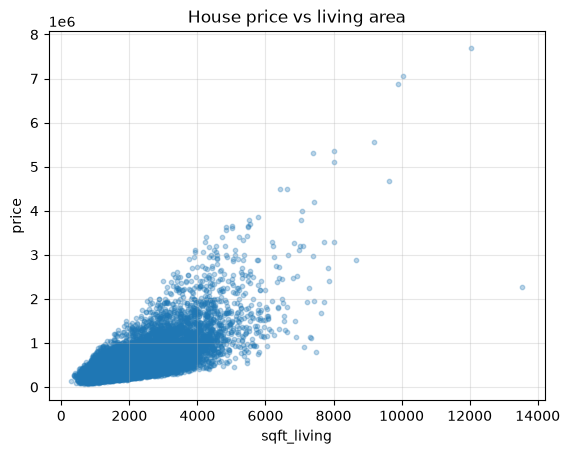

In [ ]:
plt.scatter(X, y, alpha=0.3, s=10)
plt.xlabel('sqft_living')
plt.ylabel('price')
plt.title('House price vs living area')
plt.grid(True, alpha=0.3)
plt.show()


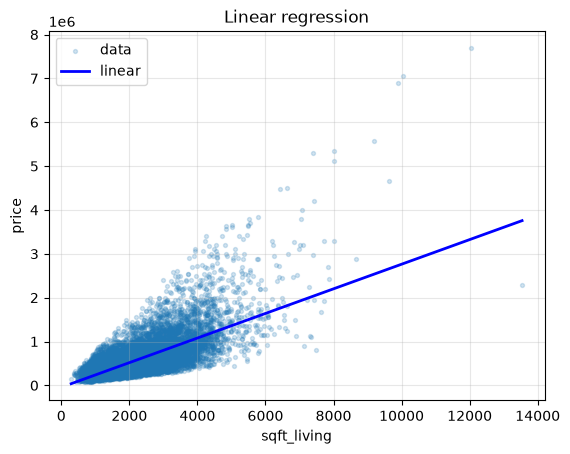

Linear R²: 0.493


In [ ]:
# straight line (degree 1)
lin_model = LinearRegression().fit(X, y)
x_smooth = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

plt.scatter(X, y, alpha=0.2, s=8, label='data')
plt.plot(x_smooth, lin_model.predict(x_smooth), color='blue', linewidth=2, label='linear')
plt.xlabel('sqft_living'); plt.ylabel('price')
plt.title('Linear regression')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print('Linear R²:', round(r2_score(y, lin_model.predict(X)), 3))


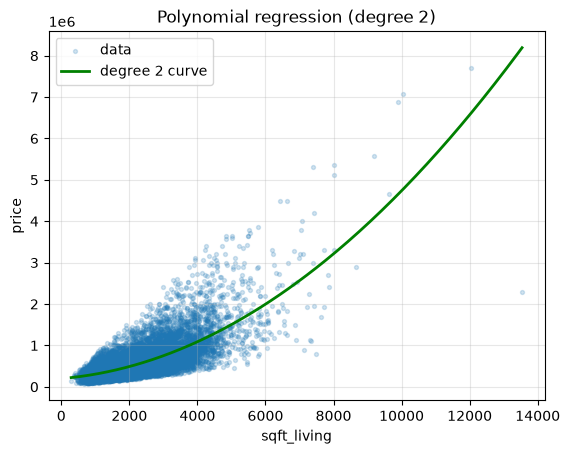

Polynomial R²: 0.533


In [ ]:
# polynomial regression by hand: add sqft_living² as a feature
x = df['sqft_living'].values
X_poly = np.column_stack([x, x ** 2])

poly_model = LinearRegression().fit(X_poly, y)

x_smooth = np.linspace(x.min(), x.max(), 200)
X_smooth = np.column_stack([x_smooth, x_smooth ** 2])

plt.scatter(x, y, alpha=0.2, s=8, label='data')
plt.plot(x_smooth, poly_model.predict(X_smooth), color='green', linewidth=2, label='degree 2 curve')
plt.xlabel('sqft_living'); plt.ylabel('price')
plt.title('Polynomial regression (degree 2)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print('Polynomial R²:', round(r2_score(y, poly_model.predict(X_poly)), 3))


In [ ]:
# train/test split — compare degrees (underfitting vs overfitting)
x_train, x_test, y_train, y_test = train_test_split(
    df['sqft_living'].values, y, test_size=0.2, random_state=42
)

def fit_poly(degree):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_tr = poly.fit_transform(x_train.reshape(-1, 1))
    X_te = poly.transform(x_test.reshape(-1, 1))
    model = LinearRegression().fit(X_tr, y_train)
    r2_tr = r2_score(y_train, model.predict(X_tr))
    r2_te = r2_score(y_test, model.predict(X_te))
    return model, poly, r2_tr, r2_te

for degree in [1, 2, 5]:
    _, _, r2_tr, r2_te = fit_poly(degree)
    print(f'degree {degree}:  train R² = {r2_tr:.3f}   test R² = {r2_te:.3f}')


degree 1:  train R² = 0.492   test R² = 0.494
degree 2:  train R² = 0.549   test R² = 0.457
degree 5:  train R² = 0.467   test R² = 0.382


In [ ]:
dfs = pd.read_csv(r"C:\Users\HP\Desktop\AI_project\week-06-regression-and-classification-ML\datasets\students.csv")

In [ ]:

dfs.head()

,student_id,gender,city,program,semester,study_hours,attendance,prev_gpa,final_marks,scholarship
0,S1099,Female,Quetta,BBA,1,8.1,87.5,1.91,68.5,0
1,S1179,Female,Karachi,BSSE,7,5.2,77.4,NaN,54.4,0
2,S1131,Female,Lahore,BBA,7,4.0,96.9,NaN,68.7,0
3,S1024,Female,PESHAWAR,BSCS,3,2.5,100.0,2.84,56.8,0
4,S1065,Male,Quetta,BSSE,4,7.7,87.8,NaN,68.8,0


In [ ]:
# future = ['semester','study_hours','attendance','prev_gpa','final_marks','scholarship']

In [ ]:
dfs.corr()["final_marks"].drop("final_marks").sort_values(ascending=False).round(3)

ValueError: could not convert string to float: 'S1099'

In [ ]:

x = dfs['final_marks']
y = dfs.drop('final_marks',axis=1)

KeyError: 'final_marks'

In [ ]:
dfs.shape

(184, 10)

In [ ]:
x.shape

(184,)